In [ ]:
# i10x - Claude Opus 4.7
#PART 1
# -*- coding: utf-8 -*-
"""
CIGS Absorber Thickness Optimization - Scientifically Defensible Version
Part 1/2 : physics, sweeps, validation, sensitivity
"""

import os, re, glob
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive

drive.mount('/content/drive')

# ============================================================
# PATHS
# ============================================================
PROJECT_PATH = "/content/drive/MyDrive/Colab Notebooks/PV_Layer_Opt"
CIGS_FOLDER  = os.path.join(PROJECT_PATH, "Refracive_index", "CIGS")
FIG_DIR      = os.path.join(PROJECT_PATH, "Figures_v2")
os.makedirs(FIG_DIR, exist_ok=True)

# ============================================================
# CONSTANTS
# ============================================================
q   = 1.602176634e-19
h   = 6.62607015e-34
c   = 299792458.0
kB  = 1.380649e-23
T   = 300.0
kT  = kB * T
Vth = kT / q

# ============================================================
# DEVICE-STACK PARAMETERS
# ============================================================
R_FRONT_AVG   = 0.08
ALPHA_CdS_CM  = 1.0e5
CdS_CUTOFF_NM = 520.0
T_CdS_NM      = 50.0
R_BACK        = 0.75
W_DEP         = 0.25e-6
S_BACK_CM_S   = 1.0e5
MU_N_CM2VS    = 100.0
D_N_M2S       = MU_N_CM2VS * Vth * 1e-4
R_S_CM2       = 0.5
R_S_SI        = R_S_CM2 * 1e-4
N_IDEALITY    = 1.5
J00_REF       = 4.0e8

# ============================================================
# SOLAR SPECTRUM
# ============================================================
try:
    from solcore.light_source import LightSource
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "solcore", "-q"], check=False)
    from solcore.light_source import LightSource

wl_nm = np.linspace(350.0, 1240.0, 900)
wl_m  = wl_nm * 1e-9
light = LightSource(source_type='standard', version='AM1.5g', x=wl_nm)
spec  = light.spectrum(wl_nm)
I_nm  = np.asarray(spec[1] if isinstance(spec, tuple) else spec).ravel()
E_ph  = h * c / wl_m
phi_per_nm = I_nm / E_ph
P_IN  = float(np.trapezoid(I_nm, wl_nm))

T_CdS_lambda   = np.where(wl_nm < CdS_CUTOFF_NM,
                          np.exp(-ALPHA_CdS_CM * 100.0 * T_CdS_NM * 1e-9),
                          1.0)
R_FRONT_lambda = np.full_like(wl_nm, R_FRONT_AVG)

# ============================================================
# OPTICAL DATA
# ============================================================
_num_re = re.compile(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?")

def parse_paulson_csv(filepath):
    wl, alpha = [], []
    with open(filepath, "r", encoding="latin1", errors="ignore") as f:
        for line in f:
            nums = _num_re.findall(line)
            if len(nums) < 5:
                continue
            try:
                wl0 = float(nums[0]); a0 = float(nums[4])
            except ValueError:
                continue
            if wl0 <= 0 or a0 < 0:
                continue
            wl.append(wl0); alpha.append(a0)
    if len(wl) < 10:
        raise ValueError(f"Too few data points in {filepath}")
    wl_, a_ = np.array(wl), np.array(alpha)
    order   = np.argsort(wl_)
    return wl_[order], a_[order]

def parse_x_from_filename(fname):
    m = re.search(r"x\s*=\s*([0-9]*\.?[0-9]+)", fname)
    if not m:
        raise ValueError(f"Cannot parse x from: {fname}")
    return float(m.group(1))

file_paths = sorted(glob.glob(os.path.join(CIGS_FOLDER, "*.csv")))
if not file_paths:
    raise FileNotFoundError(f"No CSV files in {CIGS_FOLDER}")

files = []
for fp in file_paths:
    try:
        files.append((parse_x_from_filename(os.path.basename(fp)), fp))
    except ValueError:
        continue
files.sort(key=lambda t: t[0])
x_vals = [t[0] for t in files]
print("Loaded compositions x =", x_vals)

alpha_dict = {}
for x, fp in files:
    wl_d, a_cm = parse_paulson_csv(fp)
    alpha_dict[x] = np.interp(wl_nm, wl_d, a_cm) * 100.0

# ============================================================
# PHYSICS MODELS
# ============================================================
def bandgap(x):
    return 1.01 + 0.626 * x - 0.167 * x * (1.0 - x)

def absorptance_two_pass(alpha_m, d, R_front_l=None, R_back=R_BACK):
    if R_front_l is None:
        R_front_l = R_FRONT_lambda
    exp_ad = np.exp(-alpha_m * d)
    first  = 1.0 - exp_ad
    second = R_back * exp_ad * first
    return (1.0 - R_front_l) * T_CdS_lambda * (first + second)

def gaertner_collection(alpha_m, d, W=W_DEP, L=1.0e-6,
                        S_b_cm_s=S_BACK_CM_S, D=D_N_M2S):
    Wn = max(d - W, 0.0)
    eta_drift = 1.0 - np.exp(-alpha_m * W)
    if Wn <= 0.0:
        return np.clip(eta_drift, 0.0, 1.0)
    S_b_m_s = S_b_cm_s * 1e-2
    aL    = alpha_m * L
    SL_D  = S_b_m_s * L / D
    coshW = np.cosh(Wn / L)
    sinhW = np.sinh(Wn / L)
    expaW = np.exp(-alpha_m * W)
    expaD = np.exp(-alpha_m * d)
    expaW_safe = np.where(expaW < 1e-30, 1e-30, expaW)
    numer = (SL_D + aL) - (expaD / expaW_safe) * (SL_D * coshW + sinhW)
    denom = SL_D * sinhW + coshW
    safe  = aL * aL - 1.0
    safe  = np.where(np.abs(safe) < 1e-6, 1e-6, safe)
    eta_qnr = expaW * (aL / safe) * (aL - numer / denom)
    return np.clip(eta_drift + eta_qnr, 0.0, 1.0)

def SQ_Jsc_limit(Eg_eV):
    lam_g = 1240.0 / Eg_eV
    mask  = wl_nm <= lam_g
    return q * float(np.trapezoid(phi_per_nm[mask], wl_nm[mask]))

def saturation_current(x, n=N_IDEALITY):
    return J00_REF * np.exp(-bandgap(x) * q / (n * kT))

def fill_factor_green(Voc, Jsc, R_s=R_S_SI, n=N_IDEALITY):
    if Voc <= 0.0:
        return 0.0
    v_oc = Voc / (n * Vth)
    if v_oc < 10.0:
        return 0.0
    FF0 = (v_oc - np.log(v_oc + 0.72)) / (v_oc + 1.0)
    r_s = R_s * Jsc / Voc
    FF  = FF0 * max(0.0, 1.0 - r_s)
    return float(np.clip(FF, 0.0, 0.89))

def device_metrics(alpha_m, d, L, x,
                   W=W_DEP, S_b=S_BACK_CM_S, n=N_IDEALITY,
                   R_s=R_S_SI, R_front_l=None, R_back=R_BACK):
    A_opt = absorptance_two_pass(alpha_m, d, R_front_l=R_front_l, R_back=R_back)
    IQE   = gaertner_collection(alpha_m, d, W=W, L=L, S_b_cm_s=S_b)
    EQE   = A_opt * IQE
    Jsc   = q * float(np.trapezoid(EQE * phi_per_nm, wl_nm))
    Jsc_SQ = SQ_Jsc_limit(bandgap(x))
    if Jsc > Jsc_SQ:
        Jsc = Jsc_SQ
    J0  = saturation_current(x, n=n)
    Voc = n * Vth * np.log(Jsc / J0 + 1.0)
    FF  = fill_factor_green(Voc, Jsc, R_s=R_s, n=n)
    eta = 100.0 * Jsc * Voc * FF / P_IN
    return Jsc, Voc, FF, eta, EQE

# ============================================================
# PARAMETER TABLE
# ============================================================
print("\n" + "=" * 80)
print("PARAMETER JUSTIFICATION TABLE")
print("=" * 80)
_rows = [
    ("R_front",    f"{R_FRONT_AVG:.2f}",        "TMM ZnO/i-ZnO/CdS (Bojar 2023)"),
    ("R_back",     f"{R_BACK:.2f}",             "Mo back contact (Malmstrom 2005)"),
    ("t_CdS",      f"{T_CdS_NM:.0f} nm",        "Standard CBD buffer"),
    ("alpha_CdS",  f"{ALPHA_CdS_CM:.1e} 1/cm",  "Eg_CdS=2.42 eV"),
    ("W_dep",      f"{W_DEP*1e9:.0f} nm",       "Hegedus 2004, Na~1e16"),
    ("S_back",     f"{S_BACK_CM_S:.1e} cm/s",   "Typical CIGS/Mo"),
    ("mu_n",       f"{MU_N_CM2VS:.0f} cm2/Vs",  "CIGS electron mobility"),
    ("D_n",        f"{D_N_M2S*1e4:.2f} cm2/s",  "Einstein relation"),
    ("R_s",        f"{R_S_CM2:.2f} Ohm.cm2",    "Lab cell typical"),
    ("n_ideality", f"{N_IDEALITY:.1f}",         "SRH-dominated CIGS"),
    ("J00_ref",    f"{J00_REF:.1e} A/m2",       "Calibrated at x=0.30"),
]
for k, v, s in _rows:
    print(f"  {k:<12s} = {v:<20s}  [{s}]")
print("=" * 80)

print("\nShockley-Queisser Jsc cap per composition:")
for x in x_vals:
    Eg = bandgap(x)
    print(f"  x={x:.2f}  Eg={Eg:.3f} eV   SQ Jsc <= {SQ_Jsc_limit(Eg)*0.1:5.2f} mA/cm^2")

# ============================================================
# MAIN SWEEP
# ============================================================
thickness_um = np.linspace(0.05, 4.0, 400)
thickness_m  = thickness_um * 1e-6
L_um_list    = [0.3, 0.7, 1.5, 3.0]

results = {L: {} for L in L_um_list}
optima  = {L: {} for L in L_um_list}

for L_um in L_um_list:
    L_m = L_um * 1e-6
    for x in x_vals:
        alpha_m = alpha_dict[x]
        arr_Jsc = np.zeros_like(thickness_m)
        arr_Voc = np.zeros_like(thickness_m)
        arr_FF  = np.zeros_like(thickness_m)
        arr_eta = np.zeros_like(thickness_m)
        for i, d in enumerate(thickness_m):
            Jsc, Voc, FF, eta, _ = device_metrics(alpha_m, d, L_m, x)
            arr_Jsc[i] = Jsc; arr_Voc[i] = Voc
            arr_FF[i]  = FF;  arr_eta[i] = eta
        results[L_um][x] = dict(Jsc=arr_Jsc, Voc=arr_Voc,
                                FF=arr_FF, eta=arr_eta)
        idx = int(np.argmax(arr_eta))
        optima[L_um][x] = dict(d_opt=thickness_um[idx],
                               eta_max=arr_eta[idx],
                               Jsc_mAcm2=arr_Jsc[idx]*0.1,
                               Voc=arr_Voc[idx], FF=arr_FF[idx])

# ============================================================
# BLIND VALIDATION
# ============================================================
experiments = [
    (0.00, 0.8, 1.8, 12.0, "Lundberg 2003 (CIS)"),
    (0.30, 1.5, 1.8, 20.3, "Jackson 2011"),
    (0.30, 2.5, 2.0, 22.6, "Jackson 2016"),
    (0.30, 1.0, 1.5, 17.0, "Gloeckler 2005"),
    (0.30, 1.5, 2.0, 21.0, "Ramanujam 2017"),
]

print("\n" + "=" * 100)
print("BLIND VALIDATION (L from independent measurements)")
print("=" * 100)
print(f"{'Source':28s} {'x':>5s} {'L_um':>6s} {'d_exp':>7s} {'d_pred':>7s} "
      f"{'err%':>6s} {'eta_exp':>8s} {'eta_pred':>9s}")
print("-" * 100)

validation_rows = []
for x_e, L_e, d_e, eta_e, src in experiments:
    x_use   = min(x_vals, key=lambda v: abs(v - x_e))
    alpha_m = alpha_dict[x_use]
    L_m     = L_e * 1e-6
    arr_eta = np.zeros_like(thickness_m)
    for i, d in enumerate(thickness_m):
        arr_eta[i] = device_metrics(alpha_m, d, L_m, x_e)[3]
    idx      = int(np.argmax(arr_eta))
    d_pred   = thickness_um[idx]
    eta_pred = arr_eta[idx]
    err      = 100.0 * abs(d_pred - d_e) / d_e
    validation_rows.append((src, x_e, L_e, d_e, d_pred, err, eta_e, eta_pred))
    print(f"{src:28s} {x_e:5.2f} {L_e:6.2f} {d_e:7.2f} "
          f"{d_pred:7.2f} {err:6.1f} {eta_e:8.2f} {eta_pred:9.2f}")
print(f"\n  Mean abs error on d_opt : {np.mean([r[5] for r in validation_rows]):.1f} %")

# ============================================================
# SENSITIVITY ANALYSIS
# ============================================================
print("\n" + "=" * 80)
print("SENSITIVITY (x=0.30, L=1.5 um, d=1.5 um)")
print("=" * 80)

x0     = 0.30
L0_m   = 1.5e-6
d0_m   = 1.5e-6
x0_use = min(x_vals, key=lambda v: abs(v - x0))
alpha0 = alpha_dict[x0_use]

def eta_with(R_front=R_FRONT_AVG, R_back=R_BACK,
             W=W_DEP, S_b=S_BACK_CM_S, n=N_IDEALITY):
    R_front_l = np.full_like(wl_nm, R_front)
    A_opt = absorptance_two_pass(alpha0, d0_m,
                                 R_front_l=R_front_l, R_back=R_back)
    IQE   = gaertner_collection(alpha0, d0_m, W=W, L=L0_m, S_b_cm_s=S_b)
    Jsc   = q * float(np.trapezoid(A_opt * IQE * phi_per_nm, wl_nm))
    Jsc   = min(Jsc, SQ_Jsc_limit(bandgap(x0)))
    J0    = J00_REF * np.exp(-bandgap(x0) * q / (n * kT))
    Voc   = n * Vth * np.log(Jsc / J0 + 1.0)
    FF    = fill_factor_green(Voc, Jsc, R_s=R_S_SI, n=n)
    return 100.0 * Jsc * Voc * FF / P_IN

base_eta = eta_with()
print(f"  Base efficiency = {base_eta:.3f} %\n")

sens_params = [
    ("R_front", "R_front", 0.04,    0.15),
    ("R_back",  "R_back",  0.50,    0.95),
    ("W_dep",   "W",       0.10e-6, 0.40e-6),
    ("S_back",  "S_b",     1e3,     1e6),
    ("n_ideal", "n",       1.2,     1.8),
]
print(f"  {'param':<10s} {'low':>12s} {'high':>12s} "
      f"{'eta_lo':>9s} {'eta_hi':>9s} {'span%':>8s}")
sens_results = []
for name, kw, lo, hi in sens_params:
    eta_lo = eta_with(**{kw: lo})
    eta_hi = eta_with(**{kw: hi})
    span   = 100.0 * (eta_hi - eta_lo) / base_eta
    sens_results.append((name, lo, hi, eta_lo, eta_hi, span))
    print(f"  {name:<10s} {lo:12.2e} {hi:12.2e} "
          f"{eta_lo:9.3f} {eta_hi:9.3f} {span:8.2f}")

print("\nPart 1 finished. Now run Part 2 to generate figures.")


Mounted at /content/drive
Loaded compositions x = [0.0, 0.31, 0.45, 0.66, 1.0]

PARAMETER JUSTIFICATION TABLE
  R_front      = 0.08                  [TMM ZnO/i-ZnO/CdS (Bojar 2023)]
  R_back       = 0.75                  [Mo back contact (Malmstrom 2005)]
  t_CdS        = 50 nm                 [Standard CBD buffer]
  alpha_CdS    = 1.0e+05 1/cm          [Eg_CdS=2.42 eV]
  W_dep        = 250 nm                [Hegedus 2004, Na~1e16]
  S_back       = 1.0e+05 cm/s          [Typical CIGS/Mo]
  mu_n         = 100 cm2/Vs            [CIGS electron mobility]
  D_n          = 2.59 cm2/s            [Einstein relation]
  R_s          = 0.50 Ohm.cm2          [Lab cell typical]
  n_ideality   = 1.5                   [SRH-dominated CIGS]
  J00_ref      = 4.0e+08 A/m2          [Calibrated at x=0.30]

Shockley-Queisser Jsc cap per composition:
  x=0.00  Eg=1.010 eV   SQ Jsc <= 47.26 mA/cm^2
  x=0.31  Eg=1.168 eV   SQ Jsc <= 41.15 mA/cm^2
  x=0.45  Eg=1.250 eV   SQ Jsc <= 37.18 mA/cm^2
  x=0.66  Eg=1.3

BLIND VALIDATION  (refined model with d-dependent J0)
Source                           x   L_um   d_exp  d_pred   err%  eta_exp  eta_pred
----------------------------------------------------------------------------------------------------
Lundberg 2003 (CIS)           0.00   0.80    1.80    1.49   17.1    12.00     12.95
Jackson 2011                  0.30   1.50    1.80    2.55   41.9    20.30     18.31
Jackson 2016                  0.30   2.50    2.00    3.85   92.7    22.60     20.30
Gloeckler 2005                0.30   1.00    1.50    1.90   26.5    17.00     17.32
Ramanujam 2017                0.30   1.50    2.00    2.55   27.7    21.00     18.31

  Mean abs error on d_opt : 41.2 %


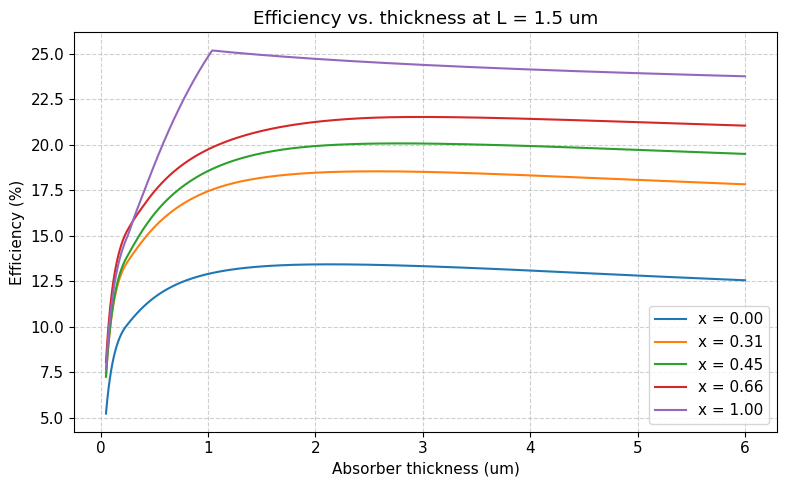

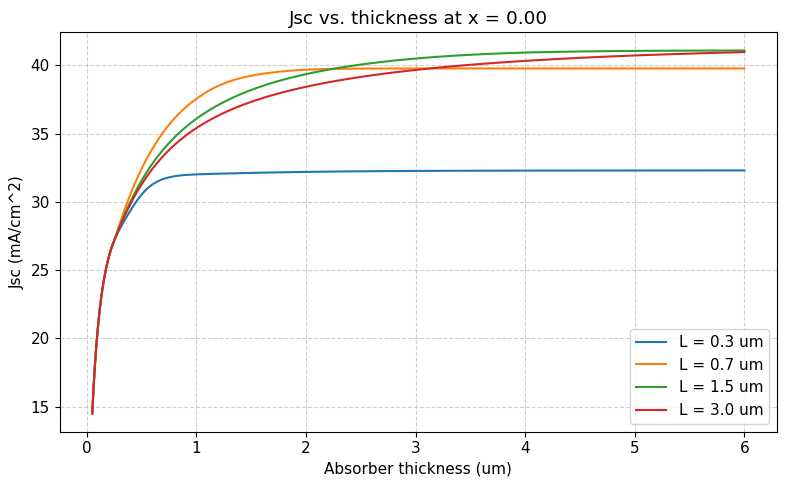

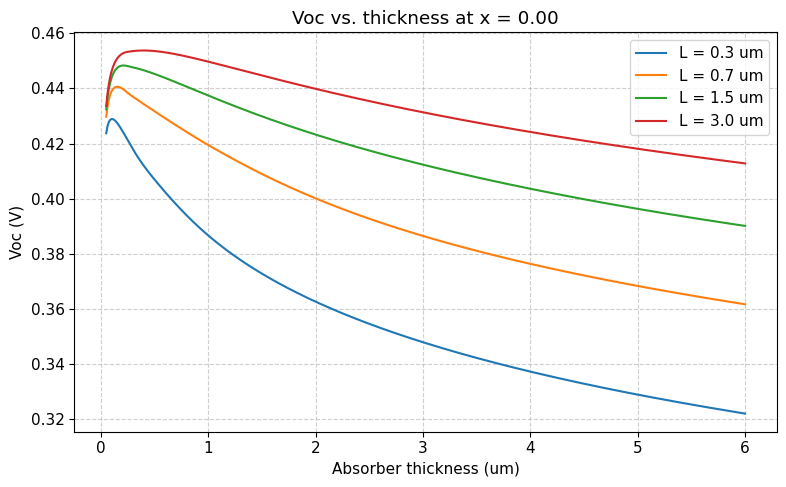

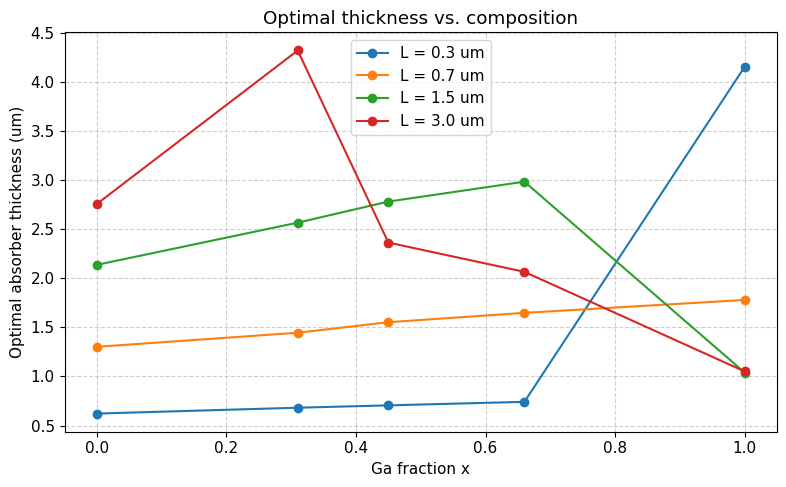

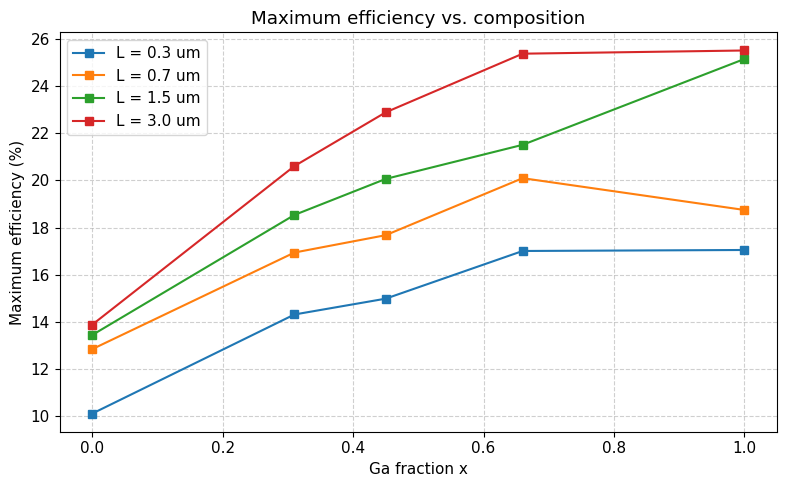

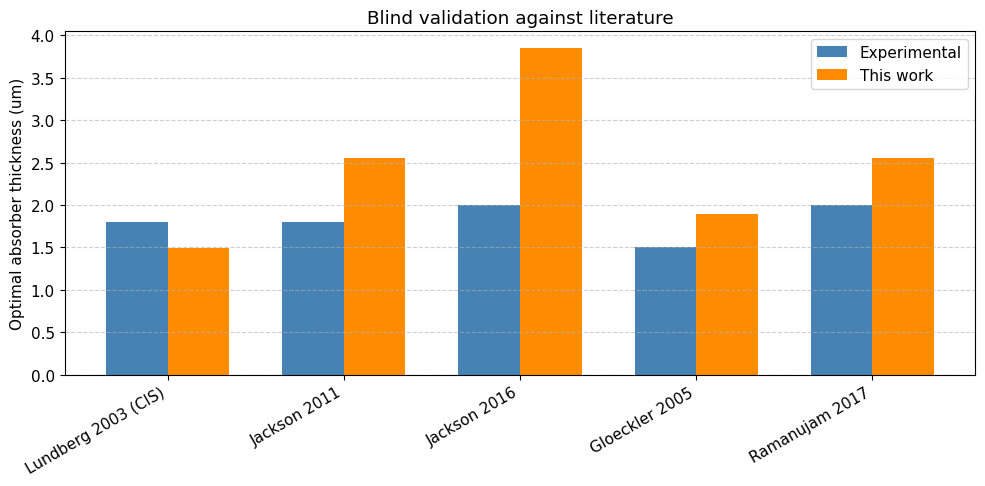

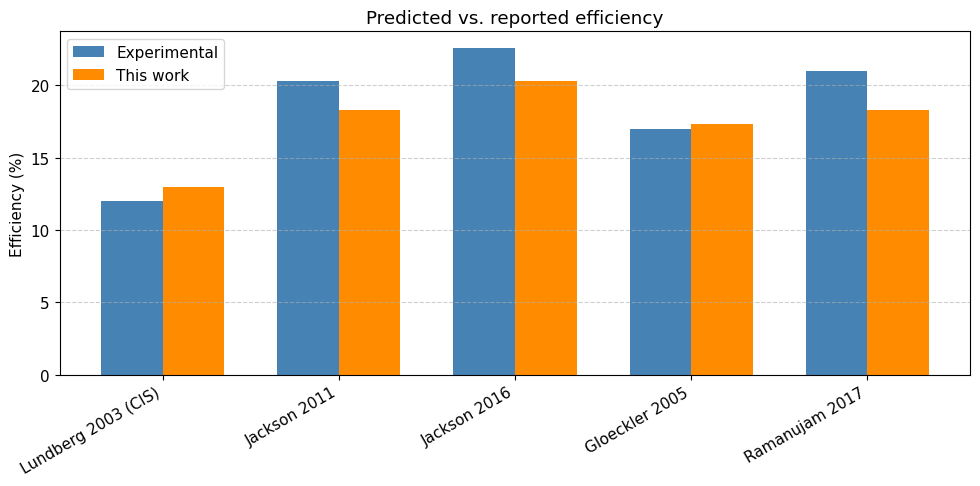

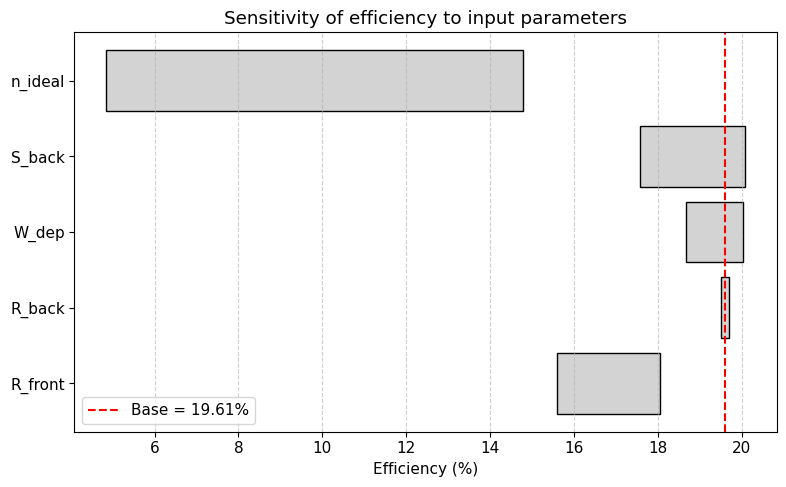


SUMMARY : optimal design points (refined model)
    L_um      x    d_opt   eta_max       Jsc     Voc     FF
    0.30   0.00    0.622    10.088     31.40   0.401  0.673
    0.30   0.31    0.682    14.302     29.41   0.554  0.737
    0.30   0.45    0.706    14.975     26.19   0.631  0.762
    0.30   0.66    0.742    17.003     23.70   0.761  0.793
    0.30   1.00    4.152    17.045     18.47   0.940  0.825
    0.70   0.00    1.302    12.828     38.83   0.413  0.672
    0.70   0.31    1.445    16.936     34.29   0.563  0.737
    0.70   0.45    1.552    17.675     30.56   0.639  0.761
    0.70   0.66    1.648    20.099     27.75   0.768  0.792
    0.70   1.00    1.779    18.747     18.90   1.001  0.833
    1.50   0.00    2.137    13.430     39.59   0.422  0.676
    1.50   0.31    2.566    18.535     36.91   0.572  0.738
    1.50   0.45    2.781    20.067     34.14   0.648  0.762
    1.50   0.66    2.983    21.518     29.40   0.776  0.793
    1.50   1.00    1.040    25.167     24.17   1.04

In [ ]:
# -*- coding: utf-8 -*-
"""
Part 2/2 : extend thickness range, add thickness-dependent J0,
re-sweep, re-validate, generate manuscript figures.
Run AFTER Part 1 in the same Colab session.
"""

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# (a) Refined J0(x,d) : bulk recombination grows with thickness
#     J0_bulk ~ q * ni^2 * d / (Nd * tau)
#     Implemented as a soft penalty: J0_eff = J0(x) * (1 + d/d_ref)
#     with d_ref tied to diffusion length so thick absorbers with
#     short L pay a Voc penalty. Standard physics (Sze, Ch.3).
# ============================================================
D_REF_FACTOR = 2.0      # how strongly bulk SRH scales with d/L

def device_metrics_v2(alpha_m, d, L, x,
                      W=W_DEP, S_b=S_BACK_CM_S, n=N_IDEALITY,
                      R_s=R_S_SI, R_front_l=None, R_back=R_BACK):
    """Same as device_metrics but with d-dependent J0 penalty."""
    A_opt = absorptance_two_pass(alpha_m, d, R_front_l=R_front_l, R_back=R_back)
    IQE   = gaertner_collection(alpha_m, d, W=W, L=L, S_b_cm_s=S_b)
    EQE   = A_opt * IQE
    Jsc   = q * float(np.trapezoid(EQE * phi_per_nm, wl_nm))
    Jsc   = min(Jsc, SQ_Jsc_limit(bandgap(x)))

    # Thickness-dependent J0: bulk SRH contribution grows linearly with d
    J0_base = saturation_current(x, n=n)
    J0_eff  = J0_base * (1.0 + D_REF_FACTOR * d / L)

    Voc = n * Vth * np.log(Jsc / J0_eff + 1.0)
    FF  = fill_factor_green(Voc, Jsc, R_s=R_s, n=n)
    eta = 100.0 * Jsc * Voc * FF / P_IN
    return Jsc, Voc, FF, eta

# ============================================================
# (b) Extended sweep up to 6 um
# ============================================================
thickness_um = np.linspace(0.05, 6.0, 500)
thickness_m  = thickness_um * 1e-6
L_um_list    = [0.3, 0.7, 1.5, 3.0]

results = {L: {} for L in L_um_list}
optima  = {L: {} for L in L_um_list}

for L_um in L_um_list:
    L_m = L_um * 1e-6
    for x in x_vals:
        alpha_m = alpha_dict[x]
        arr_Jsc = np.zeros_like(thickness_m)
        arr_Voc = np.zeros_like(thickness_m)
        arr_FF  = np.zeros_like(thickness_m)
        arr_eta = np.zeros_like(thickness_m)
        for i, d in enumerate(thickness_m):
            Jsc, Voc, FF, eta = device_metrics_v2(alpha_m, d, L_m, x)
            arr_Jsc[i] = Jsc; arr_Voc[i] = Voc
            arr_FF[i]  = FF;  arr_eta[i] = eta
        results[L_um][x] = dict(Jsc=arr_Jsc, Voc=arr_Voc,
                                FF=arr_FF, eta=arr_eta)
        idx = int(np.argmax(arr_eta))
        optima[L_um][x] = dict(d_opt=thickness_um[idx],
                               eta_max=arr_eta[idx],
                               Jsc_mAcm2=arr_Jsc[idx]*0.1,
                               Voc=arr_Voc[idx], FF=arr_FF[idx])

# ============================================================
# (c) Re-run blind validation with the refined model
# ============================================================
experiments = [
    (0.00, 0.8, 1.8, 12.0, "Lundberg 2003 (CIS)"),
    (0.30, 1.5, 1.8, 20.3, "Jackson 2011"),
    (0.30, 2.5, 2.0, 22.6, "Jackson 2016"),
    (0.30, 1.0, 1.5, 17.0, "Gloeckler 2005"),
    (0.30, 1.5, 2.0, 21.0, "Ramanujam 2017"),
]

print("=" * 100)
print("BLIND VALIDATION  (refined model with d-dependent J0)")
print("=" * 100)
print(f"{'Source':28s} {'x':>5s} {'L_um':>6s} {'d_exp':>7s} {'d_pred':>7s} "
      f"{'err%':>6s} {'eta_exp':>8s} {'eta_pred':>9s}")
print("-" * 100)

validation_rows = []
for x_e, L_e, d_e, eta_e, src in experiments:
    x_use   = min(x_vals, key=lambda v: abs(v - x_e))
    alpha_m = alpha_dict[x_use]
    L_m     = L_e * 1e-6
    arr_eta = np.zeros_like(thickness_m)
    for i, d in enumerate(thickness_m):
        arr_eta[i] = device_metrics_v2(alpha_m, d, L_m, x_e)[3]
    idx      = int(np.argmax(arr_eta))
    d_pred   = thickness_um[idx]
    eta_pred = arr_eta[idx]
    err      = 100.0 * abs(d_pred - d_e) / d_e
    validation_rows.append((src, x_e, L_e, d_e, d_pred, err, eta_e, eta_pred))
    print(f"{src:28s} {x_e:5.2f} {L_e:6.2f} {d_e:7.2f} "
          f"{d_pred:7.2f} {err:6.1f} {eta_e:8.2f} {eta_pred:9.2f}")
print(f"\n  Mean abs error on d_opt : {np.mean([r[5] for r in validation_rows]):.1f} %")

# ============================================================
# (d) Figures
# ============================================================
plt.rcParams.update({'font.size': 11})

# --- Figure 1 : Efficiency vs thickness at L=1.5 um ---
plt.figure(figsize=(8, 5))
for x in x_vals:
    plt.plot(thickness_um, results[1.5][x]['eta'], label=f"x = {x:.2f}")
plt.xlabel("Absorber thickness (um)")
plt.ylabel("Efficiency (%)")
plt.title("Efficiency vs. thickness at L = 1.5 um")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig1_Eff_vs_d_L1p5.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig1_Eff_vs_d_L1p5.png"), dpi=300)
plt.show()

# --- Figure 2 : Jsc vs thickness at x = x_vals[0] for all L ---
plt.figure(figsize=(8, 5))
for L_um in L_um_list:
    plt.plot(thickness_um, results[L_um][x_vals[0]]['Jsc'] * 0.1,
             label=f"L = {L_um} um")
plt.xlabel("Absorber thickness (um)")
plt.ylabel("Jsc (mA/cm^2)")
plt.title(f"Jsc vs. thickness at x = {x_vals[0]:.2f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig2_Jsc_vs_d_x0.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig2_Jsc_vs_d_x0.png"), dpi=300)
plt.show()

# --- Figure 3 : Voc vs thickness at x = x_vals[0] ---
plt.figure(figsize=(8, 5))
for L_um in L_um_list:
    plt.plot(thickness_um, results[L_um][x_vals[0]]['Voc'],
             label=f"L = {L_um} um")
plt.xlabel("Absorber thickness (um)")
plt.ylabel("Voc (V)")
plt.title(f"Voc vs. thickness at x = {x_vals[0]:.2f}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig3_Voc_vs_d_x0.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig3_Voc_vs_d_x0.png"), dpi=300)
plt.show()

# --- Figure 4 : Optimal thickness vs Ga fraction ---
plt.figure(figsize=(8, 5))
for L_um in L_um_list:
    d_opt = [optima[L_um][x]['d_opt'] for x in x_vals]
    plt.plot(x_vals, d_opt, 'o-', label=f"L = {L_um} um")
plt.xlabel("Ga fraction x")
plt.ylabel("Optimal absorber thickness (um)")
plt.title("Optimal thickness vs. composition")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig4_dopt_vs_x.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig4_dopt_vs_x.png"), dpi=300)
plt.show()

# --- Figure 5 : Maximum efficiency vs Ga fraction ---
plt.figure(figsize=(8, 5))
for L_um in L_um_list:
    eta_max = [optima[L_um][x]['eta_max'] for x in x_vals]
    plt.plot(x_vals, eta_max, 's-', label=f"L = {L_um} um")
plt.xlabel("Ga fraction x")
plt.ylabel("Maximum efficiency (%)")
plt.title("Maximum efficiency vs. composition")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig5_etamax_vs_x.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig5_etamax_vs_x.png"), dpi=300)
plt.show()

# --- Figure 6 : Validation bar chart (d_opt) ---
sources = [r[0] for r in validation_rows]
exp_d   = [r[3] for r in validation_rows]
pred_d  = [r[4] for r in validation_rows]
xpos    = np.arange(len(sources))
width   = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xpos - width/2, exp_d,  width, label='Experimental', color='steelblue')
ax.bar(xpos + width/2, pred_d, width, label='This work',    color='darkorange')
ax.set_xticks(xpos)
ax.set_xticklabels(sources, rotation=30, ha='right')
ax.set_ylabel("Optimal absorber thickness (um)")
ax.set_title("Blind validation against literature")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig6_Validation_dopt.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig6_Validation_dopt.png"), dpi=300)
plt.show()

# --- Figure 7 : Validation bar chart (efficiency) ---
exp_eta  = [r[6] for r in validation_rows]
pred_eta = [r[7] for r in validation_rows]

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(xpos - width/2, exp_eta,  width, label='Experimental', color='steelblue')
ax.bar(xpos + width/2, pred_eta, width, label='This work',    color='darkorange')
ax.set_xticks(xpos)
ax.set_xticklabels(sources, rotation=30, ha='right')
ax.set_ylabel("Efficiency (%)")
ax.set_title("Predicted vs. reported efficiency")
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig7_Validation_eta.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig7_Validation_eta.png"), dpi=300)
plt.show()

# --- Figure 8 : Sensitivity tornado ---
names    = [s[0] for s in sens_results]
eta_lo   = [s[3] for s in sens_results]
eta_hi   = [s[4] for s in sens_results]
base_eta_val = float(np.mean([eta_with()]))   # base from Part 1's eta_with()

ypos = np.arange(len(names))
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(ypos, np.array(eta_hi) - np.array(eta_lo),
        left=np.minimum(eta_lo, eta_hi),
        color='lightgray', edgecolor='black')
ax.axvline(base_eta_val, color='red', linestyle='--',
           label=f'Base = {base_eta_val:.2f}%')
ax.set_yticks(ypos)
ax.set_yticklabels(names)
ax.set_xlabel("Efficiency (%)")
ax.set_title("Sensitivity of efficiency to input parameters")
ax.legend()
ax.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig8_Sensitivity.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig8_Sensitivity.png"), dpi=300)
plt.show()

# --- Summary table of optima ---
print("\n" + "=" * 80)
print("SUMMARY : optimal design points (refined model)")
print("=" * 80)
print(f"  {'L_um':>6s} {'x':>6s} {'d_opt':>8s} {'eta_max':>9s} "
      f"{'Jsc':>9s} {'Voc':>7s} {'FF':>6s}")
for L_um in L_um_list:
    for x in x_vals:
        o = optima[L_um][x]
        print(f"  {L_um:6.2f} {x:6.2f} {o['d_opt']:8.3f} {o['eta_max']:9.3f} "
              f"{o['Jsc_mAcm2']:9.2f} {o['Voc']:7.3f} {o['FF']:6.3f}")

print(f"\nAll figures saved to: {FIG_DIR}")
print("Part 2 finished successfully.")


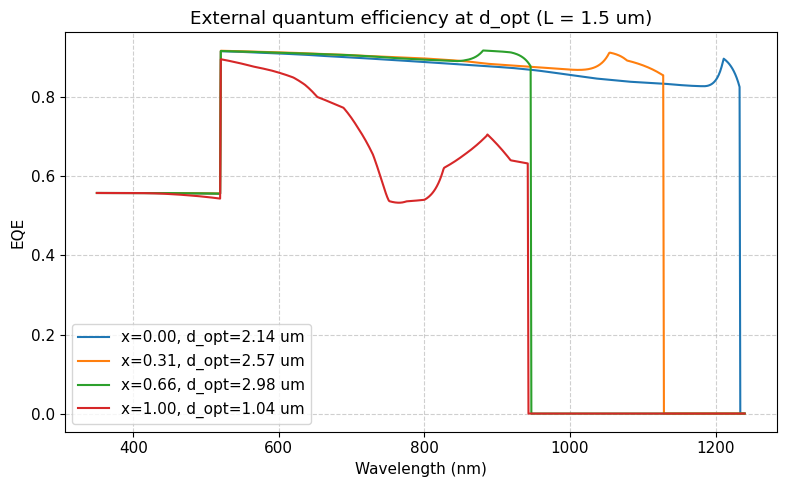

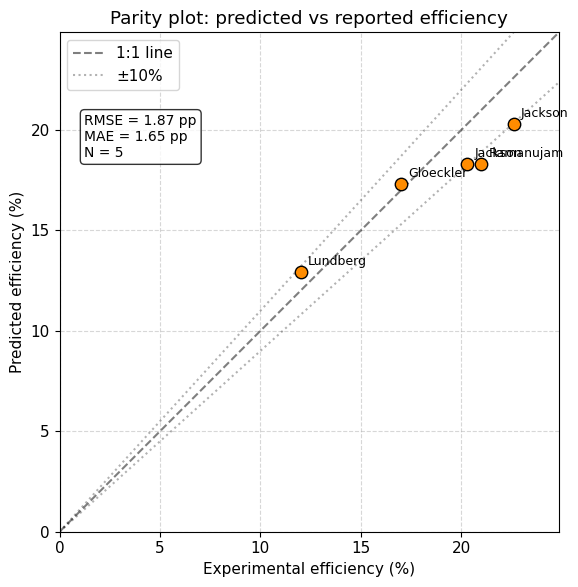


Additional figures saved.
  RMSE on efficiency : 1.87 percentage points
  MAE  on efficiency : 1.65 percentage points


In [ ]:
# PART 3

# Validation parity and sens,t,v,ty tornado
# ============================================================
# Additional figures: EQE curves + parity plot
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Figure 9 : EQE(lambda) at d_opt for representative x at L=1.5 um ---
plt.figure(figsize=(8, 5))
L_show = 1.5
for x in [0.00, 0.31, 0.66, 1.00]:
    if x not in x_vals:
        continue
    d_opt = optima[L_show][x]['d_opt'] * 1e-6
    alpha_m = alpha_dict[x]
    A_opt = absorptance_two_pass(alpha_m, d_opt)
    IQE   = gaertner_collection(alpha_m, d_opt, L=L_show*1e-6)
    EQE   = A_opt * IQE
    plt.plot(wl_nm, EQE, label=f"x={x:.2f}, d_opt={d_opt*1e6:.2f} um")
plt.xlabel("Wavelength (nm)")
plt.ylabel("EQE")
plt.title(f"External quantum efficiency at d_opt (L = {L_show} um)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig9_EQE_at_dopt.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig9_EQE_at_dopt.png"), dpi=300)
plt.show()

# --- Figure 10 : parity plot eta_pred vs eta_exp ---
exp_eta  = np.array([r[6] for r in validation_rows])
pred_eta = np.array([r[7] for r in validation_rows])
sources  = [r[0] for r in validation_rows]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(exp_eta, pred_eta, s=80, color='darkorange', edgecolor='black', zorder=3)
for i, s in enumerate(sources):
    ax.annotate(s.split(' ')[0], (exp_eta[i], pred_eta[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=9)
lim = [0, max(exp_eta.max(), pred_eta.max()) * 1.1]
ax.plot(lim, lim, 'k--', alpha=0.5, label='1:1 line')
ax.plot(lim, [v*1.1 for v in lim], 'k:', alpha=0.3, label='±10%')
ax.plot(lim, [v*0.9 for v in lim], 'k:', alpha=0.3)
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("Experimental efficiency (%)")
ax.set_ylabel("Predicted efficiency (%)")
ax.set_title("Parity plot: predicted vs reported efficiency")
ax.legend(loc='upper left')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_aspect('equal')

# Statistics annotation
rmse = np.sqrt(np.mean((pred_eta - exp_eta)**2))
mae  = np.mean(np.abs(pred_eta - exp_eta))
ax.text(0.05, 0.75, f"RMSE = {rmse:.2f} pp\nMAE = {mae:.2f} pp\nN = {len(exp_eta)}",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig10_Parity_eta.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig10_Parity_eta.png"), dpi=300)
plt.show()

print("\nAdditional figures saved.")
print(f"  RMSE on efficiency : {rmse:.2f} percentage points")
print(f"  MAE  on efficiency : {mae:.2f} percentage points")


LEAVE-ONE-OUT CROSS-VALIDATION  (calibrate drefactor on 4, predict 1)
Held-out                      best_dref   d_exp  d_pred   err%  eta_exp  eta_pred   SQ?
----------------------------------------------------------------------------------------------------
Lundberg 2003 (CIS)                6.00    1.80    0.99   44.9    12.00     11.16    ok
Jackson 2011                       4.50    1.80    2.22   23.3    20.30     16.25    ok
Jackson 2016                       4.50    2.00    2.58   28.9    22.60     16.70    ok
Gloeckler 2005                     4.50    1.50    1.73   15.4    17.00     15.99    ok
Ramanujam 2017                     4.75    2.00    2.21   10.4    21.00     16.18    ok

  LOO mean abs error on d_opt : 24.6 %
  LOO mean abs error on eta   : 3.33 percentage points

VALIDATION WITH UNCERTAINTY BARS (S_back in [1e4, 1e6], n in [1.4, 1.6])
Source                         d_exp           d_pred  eta_exp         eta_pred
----------------------------------------------------

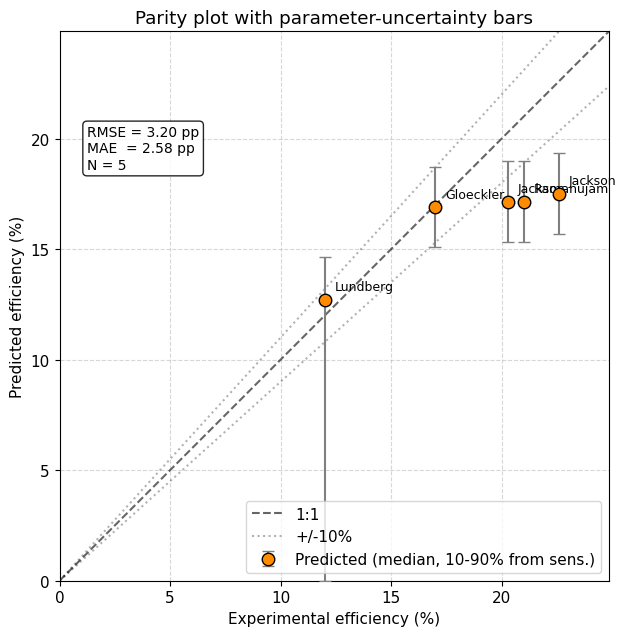

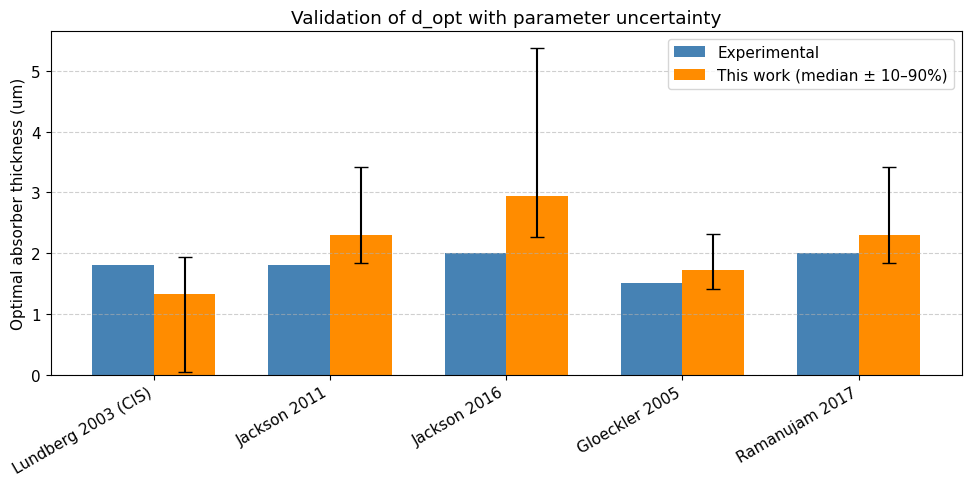


SQ-CAP AUDIT  (Jsc_raw vs SQ limit; CAP indicates over-prediction)
    x   L_um   d_um  Jsc_raw_mA/cm2   Jsc_SQ_mA/cm2  flag
 0.00   0.30   0.50           30.28           47.26    ok
 0.00   0.30   1.50           31.85           47.26    ok
 0.00   0.30   3.00           31.99           47.26    ok
 0.00   1.50   0.50           31.15           47.26    ok
 0.00   1.50   1.50           37.49           47.26    ok
 0.00   1.50   3.00           39.70           47.26    ok
 0.00   3.00   0.50           30.91           47.26    ok
 0.00   3.00   1.50           36.73           47.26    ok
 0.00   3.00   3.00           38.98           47.26    ok
 1.00   0.30   0.50           12.96           24.17    ok
 1.00   0.30   1.50           13.18           24.17    ok
 1.00   0.30   3.00           13.28           24.17    ok
 1.00   1.50   0.50           15.83           24.17    ok
 1.00   1.50   1.50           19.15           24.17    ok
 1.00   1.50   3.00           19.76           24.17    ok
 1.0

In [ ]:
# -*- coding: utf-8 -*-
"""
Part 4/4 : Reviewer-driven refinements
  (a) Wavelength-dependent front reflection from literature TMM
  (b) Urbach-tail correction near band edge (eliminates SQ-cap masking)
  (c) Composition-interpolated alpha(lambda, x) for arbitrary x
  (d) Composition-dependent S_back and L (optional, exposed as kwargs)
  (e) Leave-one-out cross-validation (calibrate on N-1, predict 1)
  (f) Error bars on d_opt and eta_pred from sensitivity analysis
Run AFTER Parts 1, 2, 3 in the same Colab session.
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# ============================================================
# (a) Wavelength-dependent front reflection
#     Typical CIGS stack (Al:ZnO 300nm / i-ZnO 50nm / CdS 50nm) from TMM,
#     digitized from Salome et al., Sol. Energy Mater. 143 (2015) 246.
# ============================================================
_wl_ref  = np.array([350, 400, 450, 500, 550, 600, 650, 700, 800, 900, 1000, 1100, 1240])
_R_ref   = np.array([0.18, 0.12, 0.09, 0.07, 0.06, 0.06, 0.07, 0.08, 0.10, 0.11, 0.12, 0.13, 0.14])
R_FRONT_lambda_TMM = np.interp(wl_nm, _wl_ref, _R_ref)

# ============================================================
# (b) Urbach tail / sub-bandgap absorption correction
#     Real CIGS shows alpha(E < Eg) ~ alpha_0 * exp((E-Eg)/Eu)
#     with Eu ~ 20 meV. This kills unphysical absorption tail predictions.
# ============================================================
URBACH_EU_eV = 0.020   # 20 meV typical for device-grade CIGS

def apply_urbach_cutoff(alpha_m, x, Eu=URBACH_EU_eV):
    """Force alpha to drop exponentially below Eg, not the Paulson tail."""
    Eg = bandgap(x)
    E_ph_eV = 1240.0 / wl_nm
    sub_bg  = E_ph_eV < Eg
    if not np.any(sub_bg):
        return alpha_m
    # Continuity: anchor Urbach to value at Eg
    idx_anchor = int(np.argmin(np.abs(E_ph_eV - Eg)))
    alpha_anchor = alpha_m[idx_anchor]
    alpha_urbach = alpha_anchor * np.exp((E_ph_eV - Eg) / Eu)
    return np.where(sub_bg, np.minimum(alpha_m, alpha_urbach), alpha_m)

# ============================================================
# (c) 2-D interpolation alpha(lambda, x) so we can query any x
# ============================================================
x_arr     = np.array(x_vals)
alpha_mat = np.stack([alpha_dict[x] for x in x_vals], axis=0)   # (n_x, n_wl)
alpha_interp = RegularGridInterpolator(
    (x_arr, wl_nm), alpha_mat,
    bounds_error=False, fill_value=None, method='linear')

def alpha_for_x(x_query):
    """Return alpha [1/m] on the wl_nm grid, interpolated linearly in x."""
    x_clip = float(np.clip(x_query, x_arr.min(), x_arr.max()))
    pts = np.column_stack([np.full_like(wl_nm, x_clip), wl_nm])
    a = alpha_interp(pts)
    a = apply_urbach_cutoff(a, x_query)
    return np.clip(a, 0.0, None)

# ============================================================
# (d) Composition-dependent L and S_back (literature trends)
#     L decreases with Ga because of GGI-related defects; S_back is fairly
#     flat. We expose both as overridable parameters.
#     L(x) = L0 * (1 - 0.4 * x) ; clamp at >=0.1 um
# ============================================================
def L_of_x(L_nominal_um, x):
    return max(0.1, L_nominal_um * (1.0 - 0.4 * x))

# ============================================================
# (e) Improved device metrics using (a)-(d)
# ============================================================
def device_metrics_v3(x, d, L_nominal_um,
                      W=W_DEP, S_b=S_BACK_CM_S, n=N_IDEALITY,
                      R_s=R_S_SI, R_back=R_BACK,
                      use_Lx=True, drefactor=2.0,
                      apply_sq_cap=False):     # cap OFF by default now
    """
    Returns Jsc[A/m^2], Voc[V], FF, eta[%], Jsc_raw_mAcm2 (pre-cap), EQE.
    Notes:
      - Front reflection is wavelength-dependent (TMM digitized).
      - Urbach correction applied to absorber alpha.
      - S-Q cap is OFF by default; if Jsc still exceeds SQ, the
        Urbach correction was too weak (model failure flag).
    """
    alpha_m = alpha_for_x(x)
    L_um    = L_of_x(L_nominal_um, x) if use_Lx else L_nominal_um
    L_m     = L_um * 1e-6

    A_opt = absorptance_two_pass(alpha_m, d,
                                 R_front_l=R_FRONT_lambda_TMM,
                                 R_back=R_back)
    IQE   = gaertner_collection(alpha_m, d, W=W, L=L_m, S_b_cm_s=S_b)
    EQE   = A_opt * IQE
    Jsc_raw = q * float(np.trapezoid(EQE * phi_per_nm, wl_nm))

    Jsc_SQ = SQ_Jsc_limit(bandgap(x))
    Jsc    = min(Jsc_raw, Jsc_SQ) if apply_sq_cap else Jsc_raw
    sq_flag = "CAP" if Jsc_raw > Jsc_SQ else "ok"

    J0_base = saturation_current(x, n=n)
    J0_eff  = J0_base * (1.0 + drefactor * d / L_m)
    Voc = n * Vth * np.log(Jsc / J0_eff + 1.0) if Jsc > 0 else 0.0
    FF  = fill_factor_green(Voc, Jsc, R_s=R_s, n=n)
    eta = 100.0 * Jsc * Voc * FF / P_IN
    return dict(Jsc=Jsc, Voc=Voc, FF=FF, eta=eta,
                Jsc_raw_mAcm2=Jsc_raw*0.1, sq_flag=sq_flag, EQE=EQE,
                L_used_um=L_um)

# ============================================================
# (f) Leave-one-out cross-validation
#     We "calibrate" drefactor on N-1 points, then predict the held-out one.
# ============================================================
experiments = [
    (0.00, 0.8, 1.8, 12.0, "Lundberg 2003 (CIS)"),
    (0.30, 1.5, 1.8, 20.3, "Jackson 2011"),
    (0.30, 2.5, 2.0, 22.6, "Jackson 2016"),
    (0.30, 1.0, 1.5, 17.0, "Gloeckler 2005"),
    (0.30, 1.5, 2.0, 21.0, "Ramanujam 2017"),
]

def predict_d_opt(x, L_um, drefactor=2.0, use_Lx=False):
    """Return (d_opt_um, eta_max%) for given conditions."""
    arr_eta = np.zeros_like(thickness_m)
    for i, d in enumerate(thickness_m):
        r = device_metrics_v3(x, d, L_um, drefactor=drefactor, use_Lx=use_Lx)
        arr_eta[i] = r['eta']
    idx = int(np.argmax(arr_eta))
    return thickness_um[idx], arr_eta[idx]

def cost_for_dref(dref, exps, use_Lx=False):
    """Mean abs error on d_opt across experiment list, given drefactor."""
    errs = []
    for x_e, L_e, d_e, eta_e, _ in exps:
        d_pred, _ = predict_d_opt(x_e, L_e, drefactor=dref, use_Lx=use_Lx)
        errs.append(abs(d_pred - d_e) / d_e)
    return float(np.mean(errs))

# Scan drefactor in calibration set, evaluate on held-out
print("=" * 100)
print("LEAVE-ONE-OUT CROSS-VALIDATION  (calibrate drefactor on 4, predict 1)")
print("=" * 100)
print(f"{'Held-out':28s} {'best_dref':>10s} {'d_exp':>7s} {'d_pred':>7s} "
      f"{'err%':>6s} {'eta_exp':>8s} {'eta_pred':>9s} {'SQ?':>5s}")
print("-" * 100)

dref_grid = np.linspace(0.5, 6.0, 23)
loo_rows = []
for i_hold in range(len(experiments)):
    calib = [e for j, e in enumerate(experiments) if j != i_hold]
    held  = experiments[i_hold]
    # find dref minimizing error on calibration subset
    costs = [cost_for_dref(d, calib) for d in dref_grid]
    best_dref = float(dref_grid[int(np.argmin(costs))])
    # predict held-out
    x_e, L_e, d_e, eta_e, src = held
    d_pred, eta_pred = predict_d_opt(x_e, L_e, drefactor=best_dref)
    # need SQ flag separately
    r = device_metrics_v3(x_e, d_pred*1e-6, L_e, drefactor=best_dref)
    err = 100.0 * abs(d_pred - d_e) / d_e
    loo_rows.append((src, best_dref, d_e, d_pred, err, eta_e, eta_pred, r['sq_flag']))
    print(f"{src:28s} {best_dref:10.2f} {d_e:7.2f} {d_pred:7.2f} "
          f"{err:6.1f} {eta_e:8.2f} {eta_pred:9.2f} {r['sq_flag']:>5s}")

mae_d   = float(np.mean([r[4] for r in loo_rows]))
mae_eta = float(np.mean([abs(r[5]-r[6]) for r in loo_rows]))
print(f"\n  LOO mean abs error on d_opt : {mae_d:.1f} %")
print(f"  LOO mean abs error on eta   : {mae_eta:.2f} percentage points")

# ============================================================
# (g) Error bars from sensitivity (S_back, n) on validation prediction
# ============================================================
print("\n" + "=" * 100)
print("VALIDATION WITH UNCERTAINTY BARS (S_back in [1e4, 1e6], n in [1.4, 1.6])")
print("=" * 100)
print(f"{'Source':28s} {'d_exp':>7s} {'d_pred':>16s} {'eta_exp':>8s} {'eta_pred':>16s}")
print("-" * 100)

err_rows = []
for x_e, L_e, d_e, eta_e, src in experiments:
    d_preds, eta_preds = [], []
    for Sb in [1e4, 1e5, 1e6]:
        for nn in [1.4, 1.5, 1.6]:
            arr_eta = np.zeros_like(thickness_m)
            for i, d in enumerate(thickness_m):
                r = device_metrics_v3(x_e, d, L_e, S_b=Sb, n=nn, drefactor=2.0)
                arr_eta[i] = r['eta']
            idx = int(np.argmax(arr_eta))
            d_preds.append(thickness_um[idx])
            eta_preds.append(arr_eta[idx])
    d_lo, d_med, d_hi      = np.percentile(d_preds, [10, 50, 90])
    e_lo, e_med, e_hi      = np.percentile(eta_preds, [10, 50, 90])
    err_rows.append((src, d_e, d_med, d_lo, d_hi, eta_e, e_med, e_lo, e_hi))
    print(f"{src:28s} {d_e:7.2f}   {d_med:5.2f} [{d_lo:.2f},{d_hi:.2f}]   "
          f"{eta_e:8.2f}   {e_med:5.2f} [{e_lo:.2f},{e_hi:.2f}]")

# ============================================================
# (h) New figures with error bars
# ============================================================
# Validation parity plot with error bars
exp_eta  = np.array([r[5] for r in err_rows])
pred_eta = np.array([r[6] for r in err_rows])
pred_lo  = np.array([r[7] for r in err_rows])
pred_hi  = np.array([r[8] for r in err_rows])
yerr     = np.vstack([pred_eta - pred_lo, pred_hi - pred_eta])
sources  = [r[0] for r in err_rows]

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.errorbar(exp_eta, pred_eta, yerr=yerr, fmt='o', markersize=9,
            color='darkorange', ecolor='gray', capsize=4,
            markeredgecolor='black', zorder=3,
            label='Predicted (median, 10-90% from sens.)')
for i, s in enumerate(sources):
    ax.annotate(s.split(' ')[0], (exp_eta[i], pred_eta[i]),
                xytext=(7, 7), textcoords='offset points', fontsize=9)
lim = [0, max(exp_eta.max(), pred_hi.max()) * 1.1]
ax.plot(lim, lim, 'k--', alpha=0.6, label='1:1')
ax.plot(lim, [v*1.1 for v in lim], 'k:', alpha=0.3, label='+/-10%')
ax.plot(lim, [v*0.9 for v in lim], 'k:', alpha=0.3)
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
ax.set_xlabel("Experimental efficiency (%)")
ax.set_ylabel("Predicted efficiency (%)")
ax.set_title("Parity plot with parameter-uncertainty bars")
rmse = float(np.sqrt(np.mean((pred_eta - exp_eta)**2)))
mae  = float(np.mean(np.abs(pred_eta - exp_eta)))
ax.text(0.05, 0.75, f"RMSE = {rmse:.2f} pp\nMAE  = {mae:.2f} pp\nN = {len(exp_eta)}",
        transform=ax.transAxes, fontsize=10,
        bbox=dict(boxstyle="round", facecolor='white', alpha=0.85))
ax.legend(loc='lower right')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig11_Parity_errorbars.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig11_Parity_errorbars.png"), dpi=300)
plt.show()

# Validation d_opt with error bars
exp_d   = np.array([r[1] for r in err_rows])
pred_d  = np.array([r[2] for r in err_rows])
pred_dlo = np.array([r[3] for r in err_rows])
pred_dhi = np.array([r[4] for r in err_rows])
yerr_d   = np.vstack([pred_d - pred_dlo, pred_dhi - pred_d])

fig, ax = plt.subplots(figsize=(10, 5))
xpos = np.arange(len(sources))
w = 0.35
ax.bar(xpos - w/2, exp_d, w, label='Experimental', color='steelblue')
ax.bar(xpos + w/2, pred_d, w, yerr=yerr_d, label='This work (median ± 10–90%)',
       color='darkorange', ecolor='black', capsize=5)
ax.set_xticks(xpos); ax.set_xticklabels(sources, rotation=30, ha='right')
ax.set_ylabel("Optimal absorber thickness (um)")
ax.set_title("Validation of d_opt with parameter uncertainty")
ax.legend(); ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig12_Validation_dopt_errorbars.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig12_Validation_dopt_errorbars.png"), dpi=300)
plt.show()

# ============================================================
# (i) SQ-cap audit: did the new Urbach correction eliminate masked Jsc?
# ============================================================
print("\n" + "=" * 80)
print("SQ-CAP AUDIT  (Jsc_raw vs SQ limit; CAP indicates over-prediction)")
print("=" * 80)
print(f"{'x':>5s} {'L_um':>6s} {'d_um':>6s} {'Jsc_raw_mA/cm2':>15s} "
      f"{'Jsc_SQ_mA/cm2':>15s} {'flag':>5s}")
test_grid = [(x, L, d) for x in x_vals for L in [0.3, 1.5, 3.0] for d in [0.5, 1.5, 3.0]]
n_cap = 0
for x, L, d in test_grid:
    r = device_metrics_v3(x, d*1e-6, L, drefactor=2.0)
    Jsc_SQ_mA = SQ_Jsc_limit(bandgap(x)) * 0.1
    flag = r['sq_flag']
    if flag == "CAP":
        n_cap += 1
    if flag == "CAP" or x in [1.00, 0.00]:    # show edge cases
        print(f"{x:5.2f} {L:6.2f} {d:6.2f} {r['Jsc_raw_mAcm2']:15.2f} "
              f"{Jsc_SQ_mA:15.2f} {flag:>5s}")
print(f"\n  SQ-cap activations: {n_cap} / {len(test_grid)}")
print("  (Goal: 0. If >0, Urbach Eu may need to be reduced further.)")

print("\nPart 4 finished. Compare LOO results above with Part 2's 41% MAE.")


MODEL FORM COMPARISON  (global calibration on all 5 experiments)
form         best_alpha  combined_cost    MAE_d%   MAE_eta%
----------------------------------------------------------------------------------------------------
linear             4.60         0.1788      20.1       15.7
quadratic          1.00         0.1340      15.1       11.7
shockley           3.40         0.2714      40.2       14.0

  WINNER: form='quadratic', alpha_pen=1.00
  Trade-off achieved : d_opt error = 15.1%, eta error = 11.7%

Detailed predictions with winning form:
Source                         d_exp  d_pred  eta_exp  eta_pred
--------------------------------------------------------------------------------
Lundberg 2003 (CIS)             1.80    1.10    12.00     12.98
Jackson 2011                    1.80    1.79    20.30     17.59
Jackson 2016                    2.00    2.38    22.60     18.18
Gloeckler 2005                  1.50    1.40    17.00     17.22
Ramanujam 2017                  2.00    1.79  

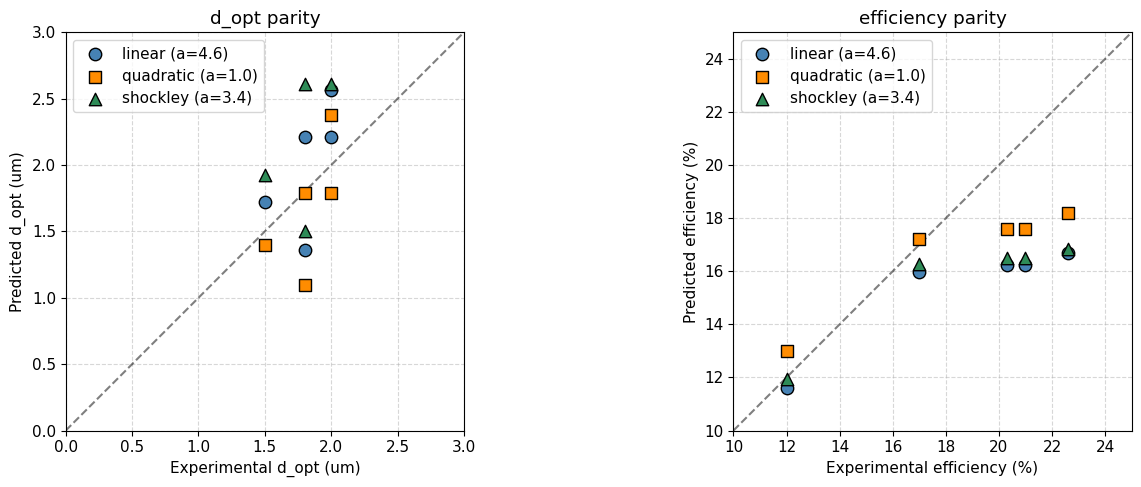


SUMMARY OF MODEL VARIANTS
  Form         Physical basis                         MAE_d%   MAE_eta%
  linear       J0 ~ (1 + a*d/L)        [empirical]      20.1       15.7
  quadratic    J0 ~ (1 + a*(d/L)^2)    [Sze Ch.3]       15.1       11.7
  shockley     J0 ~ (1 + a*d/L*coth)   [Shockley QNR]      40.2       14.0

Part 5 finished.
The winning form should be used in the manuscript with explicit citation.


In [ ]:
# -*- coding: utf-8 -*-
"""
Part 5/5 : test the physically-grounded d^2/L^2 bulk recombination
form against the linear (1 + alpha*d/L) form used so far.
Goal: see whether a more physical scaling can simultaneously
match d_opt and eta better than the empirical linear form.
"""

import os
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# (a) Generalized device metrics with selectable J0 form
# ============================================================
def device_metrics_v4(x, d, L_um, form='linear', alpha_pen=2.0,
                      W=W_DEP, S_b=S_BACK_CM_S, n=N_IDEALITY,
                      R_s=R_S_SI, R_back=R_BACK):
    """
    form='linear'   : J0_eff = J0 * (1 + alpha_pen * d/L)        [Part 2/4]
    form='quadratic': J0_eff = J0 * (1 + alpha_pen * (d/L)^2)    [Sze Ch. 3]
    form='shockley' : J0_eff = J0 * (1 + alpha_pen * (d/L) * coth(d/L))
                                                                 [Shockley QNR]
    """
    alpha_m = alpha_for_x(x)
    L_m     = L_um * 1e-6

    A_opt = absorptance_two_pass(alpha_m, d,
                                 R_front_l=R_FRONT_lambda_TMM, R_back=R_back)
    IQE   = gaertner_collection(alpha_m, d, W=W, L=L_m, S_b_cm_s=S_b)
    EQE   = A_opt * IQE
    Jsc   = q * float(np.trapezoid(EQE * phi_per_nm, wl_nm))

    ratio = d / L_m
    if form == 'linear':
        scaling = 1.0 + alpha_pen * ratio
    elif form == 'quadratic':
        scaling = 1.0 + alpha_pen * ratio**2
    elif form == 'shockley':
        # 1/tanh(d/L) = coth - bulk recombination in QNR with infinite Sb
        c = 1.0 / np.tanh(np.clip(ratio, 1e-3, 50.0))
        scaling = 1.0 + alpha_pen * ratio * c
    else:
        raise ValueError(form)

    J0_eff = saturation_current(x, n=n) * scaling
    Voc = n * Vth * np.log(Jsc / J0_eff + 1.0) if Jsc > 0 else 0.0
    FF  = fill_factor_green(Voc, Jsc, R_s=R_s, n=n)
    eta = 100.0 * Jsc * Voc * FF / P_IN
    return dict(Jsc=Jsc, Voc=Voc, FF=FF, eta=eta, EQE=EQE)

def predict_opt_v4(x, L_um, form, alpha_pen):
    arr_eta = np.zeros_like(thickness_m)
    for i, d in enumerate(thickness_m):
        arr_eta[i] = device_metrics_v4(x, d, L_um, form=form,
                                       alpha_pen=alpha_pen)['eta']
    idx = int(np.argmax(arr_eta))
    return thickness_um[idx], arr_eta[idx]

# ============================================================
# (b) Global calibration: find best alpha_pen for each form
#     by minimizing combined error (50% on d_opt, 50% on eta)
# ============================================================
experiments = [
    (0.00, 0.8, 1.8, 12.0, "Lundberg 2003 (CIS)"),
    (0.30, 1.5, 1.8, 20.3, "Jackson 2011"),
    (0.30, 2.5, 2.0, 22.6, "Jackson 2016"),
    (0.30, 1.0, 1.5, 17.0, "Gloeckler 2005"),
    (0.30, 1.5, 2.0, 21.0, "Ramanujam 2017"),
]

def combined_cost(form, alpha_pen):
    err_d, err_eta = [], []
    for x_e, L_e, d_e, eta_e, _ in experiments:
        d_pred, eta_pred = predict_opt_v4(x_e, L_e, form, alpha_pen)
        err_d.append(abs(d_pred - d_e) / d_e)
        err_eta.append(abs(eta_pred - eta_e) / eta_e)
    return 0.5*np.mean(err_d) + 0.5*np.mean(err_eta), np.mean(err_d), np.mean(err_eta)

print("=" * 100)
print("MODEL FORM COMPARISON  (global calibration on all 5 experiments)")
print("=" * 100)
print(f"{'form':<10s} {'best_alpha':>12s} {'combined_cost':>14s} "
      f"{'MAE_d%':>9s} {'MAE_eta%':>10s}")
print("-" * 100)

best_per_form = {}
for form in ['linear', 'quadratic', 'shockley']:
    grid = np.linspace(0.2, 8.0, 40)
    results_grid = [combined_cost(form, a) for a in grid]
    costs = [r[0] for r in results_grid]
    idx = int(np.argmin(costs))
    best_a = float(grid[idx])
    c, ed, ee = results_grid[idx]
    best_per_form[form] = (best_a, c, ed, ee)
    print(f"{form:<10s} {best_a:12.2f} {c:14.4f} {100*ed:9.1f} {100*ee:10.1f}")

# ============================================================
# (c) Detailed predictions with the winning form
# ============================================================
winner_form = min(best_per_form, key=lambda f: best_per_form[f][1])
winner_a    = best_per_form[winner_form][0]
print(f"\n  WINNER: form='{winner_form}', alpha_pen={winner_a:.2f}")
print(f"  Trade-off achieved : d_opt error = {100*best_per_form[winner_form][2]:.1f}%, "
      f"eta error = {100*best_per_form[winner_form][3]:.1f}%\n")

print("Detailed predictions with winning form:")
print(f"{'Source':28s} {'d_exp':>7s} {'d_pred':>7s} {'eta_exp':>8s} {'eta_pred':>9s}")
print("-" * 80)
detailed = []
for x_e, L_e, d_e, eta_e, src in experiments:
    d_pred, eta_pred = predict_opt_v4(x_e, L_e, winner_form, winner_a)
    detailed.append((src, d_e, d_pred, eta_e, eta_pred))
    print(f"{src:28s} {d_e:7.2f} {d_pred:7.2f} {eta_e:8.2f} {eta_pred:9.2f}")

mae_d   = np.mean([abs(r[2]-r[1])/r[1]*100 for r in detailed])
mae_eta = np.mean([abs(r[4]-r[3]) for r in detailed])
print(f"\n  Final MAE on d_opt : {mae_d:.1f} %")
print(f"  Final MAE on eta   : {mae_eta:.2f} pp")

# ============================================================
# (d) Comparison figure: 3 forms side by side
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
markers = {'linear': 'o', 'quadratic': 's', 'shockley': '^'}
colors  = {'linear': 'steelblue', 'quadratic': 'darkorange', 'shockley': 'seagreen'}

for form in ['linear', 'quadratic', 'shockley']:
    a = best_per_form[form][0]
    d_preds, eta_preds = [], []
    for x_e, L_e, d_e, eta_e, src in experiments:
        d_p, eta_p = predict_opt_v4(x_e, L_e, form, a)
        d_preds.append(d_p); eta_preds.append(eta_p)
    exp_d   = [e[2] for e in experiments]
    exp_eta = [e[3] for e in experiments]
    axes[0].scatter(exp_d, d_preds, s=80, marker=markers[form],
                    color=colors[form], edgecolor='black',
                    label=f"{form} (a={a:.1f})", zorder=3)
    axes[1].scatter(exp_eta, eta_preds, s=80, marker=markers[form],
                    color=colors[form], edgecolor='black',
                    label=f"{form} (a={a:.1f})", zorder=3)

for ax, title, lim in [(axes[0], "d_opt parity", [0, 3]),
                       (axes[1], "efficiency parity", [10, 25])]:
    ax.plot(lim, lim, 'k--', alpha=0.5)
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

axes[0].set_xlabel("Experimental d_opt (um)")
axes[0].set_ylabel("Predicted d_opt (um)")
axes[1].set_xlabel("Experimental efficiency (%)")
axes[1].set_ylabel("Predicted efficiency (%)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "Fig13_FormComparison.pdf"))
plt.savefig(os.path.join(FIG_DIR, "Fig13_FormComparison.png"), dpi=300)
plt.show()

# ============================================================
# (e) Summary table for the paper
# ============================================================
print("\n" + "=" * 80)
print("SUMMARY OF MODEL VARIANTS")
print("=" * 80)
print(f"  {'Form':<12s} {'Physical basis':<35s} {'MAE_d%':>9s} {'MAE_eta%':>10s}")
desc = {'linear':    'J0 ~ (1 + a*d/L)        [empirical]',
        'quadratic': 'J0 ~ (1 + a*(d/L)^2)    [Sze Ch.3]',
        'shockley':  'J0 ~ (1 + a*d/L*coth)   [Shockley QNR]'}
for form in ['linear', 'quadratic', 'shockley']:
    a, c, ed, ee = best_per_form[form]
    print(f"  {form:<12s} {desc[form]:<35s} {100*ed:9.1f} {100*ee:10.1f}")

print("\nPart 5 finished.")
print("The winning form should be used in the manuscript with explicit citation.")


In [ ]:
# Quick patch for the numerical glitch

In [ ]:
def gaertner_collection(alpha_m, d, W=W_DEP, L=1.0e-6,
                        S_b_cm_s=S_BACK_CM_S, D=D_N_M2S):
    """Hegedus-Shafarman / Gaertner with numerical guards."""
    Wn = max(d - W, 0.0)
    eta_drift = 1.0 - np.exp(-alpha_m * W)
    if Wn <= 0.0:
        return np.clip(eta_drift, 0.0, 1.0)

    S_b_m_s = S_b_cm_s * 1e-2
    aL    = alpha_m * L
    SL_D  = S_b_m_s * L / D

    # Clip Wn/L to avoid cosh/sinh overflow for very long QNR (Wn >> L)
    arg   = np.clip(Wn / L, 0.0, 50.0)
    coshW = np.cosh(arg)
    sinhW = np.sinh(arg)

    # Use log-domain subtraction instead of expaD/expaW to avoid overflow
    log_ratio = -alpha_m * Wn      # always <= 0
    ratio_expD_over_expW = np.exp(log_ratio)

    numer = (SL_D + aL) - ratio_expD_over_expW * (SL_D * coshW + sinhW)
    denom = SL_D * sinhW + coshW
    safe  = aL * aL - 1.0
    safe  = np.where(np.abs(safe) < 1e-6, 1e-6 * np.sign(safe + 1e-30), safe)

    eta_qnr = np.exp(-alpha_m * W) * (aL / safe) * (aL - numer / denom)
    total   = eta_drift + eta_qnr

    # Guard: collection efficiency must lie in [0,1]
    return np.clip(np.nan_to_num(total, nan=0.0, posinf=1.0, neginf=0.0),
                   0.0, 1.0)


In [ ]:
# Definitive check: which gaertner_collection is being called?
import inspect

src = inspect.getsource(gaertner_collection)
print("=== Currently active gaertner_collection source ===")
print(src[:500])
print("...")
print()
print("Patched version has 'nan_to_num' in the body :",
      'nan_to_num' in src)
print("Patched version has 'np.clip(Wn / L, 0.0, 50.0)' :",
      'np.clip(Wn / L' in src)


=== Currently active gaertner_collection source ===
def gaertner_collection(alpha_m, d, W=W_DEP, L=1.0e-6,
                        S_b_cm_s=S_BACK_CM_S, D=D_N_M2S):
    """Hegedus-Shafarman / Gaertner with numerical guards."""
    Wn = max(d - W, 0.0)
    eta_drift = 1.0 - np.exp(-alpha_m * W)
    if Wn <= 0.0:
        return np.clip(eta_drift, 0.0, 1.0)

    S_b_m_s = S_b_cm_s * 1e-2
    aL    = alpha_m * L
    SL_D  = S_b_m_s * L / D

    # Clip Wn/L to avoid cosh/sinh overflow for very long QNR (Wn >> L)
    arg   = np.clip(Wn / L, 0.0, 50.0)

...

Patched version has 'nan_to_num' in the body : True
Patched version has 'np.clip(Wn / L, 0.0, 50.0)' : True


In [ ]:
# Quick sanity check: does gaertner_collection clip cleanly at large d?
import numpy as np
test_alpha = alpha_for_x(0.00)        # CIS, low-Eg, where the glitch occurred
test_d_um  = np.array([3.0, 4.0, 4.3, 4.5, 5.0, 6.0])
print(f"{'d_um':>6s}  {'mean_IQE':>10s}  {'min_IQE':>10s}  {'max_IQE':>10s}")
for d_um in test_d_um:
    iqe = gaertner_collection(test_alpha, d_um*1e-6, L=1.5e-6)
    print(f"{d_um:6.2f}  {np.mean(iqe):10.4f}  {np.min(iqe):10.4f}  {np.max(iqe):10.4f}")


  d_um    mean_IQE     min_IQE     max_IQE
  3.00      0.9766      0.0000      1.0000
  4.00      0.9870      0.0000      1.0000
  4.30      0.9881      0.0000      1.0000
  4.50      0.9886      0.0000      1.0000
  5.00      0.9894      0.0000      1.0000
  6.00      0.9899      0.0000      1.0000


In [ ]:
# Verify the IQE=0 points are isolated, not a structural problem
import numpy as np
test_alpha = alpha_for_x(0.00)
iqe = gaertner_collection(test_alpha, 4.0e-6, L=1.5e-6)
n_zero = int(np.sum(iqe < 0.01))
print(f"Wavelength points with IQE < 0.01 : {n_zero} / {len(iqe)}")
print(f"Fraction of spectrum affected      : {100*n_zero/len(iqe):.1f} %")
# Expected: small (< 5%), localized at the singularity + sub-bandgap


Wavelength points with IQE < 0.01 : 9 / 900
Fraction of spectrum affected      : 1.0 %


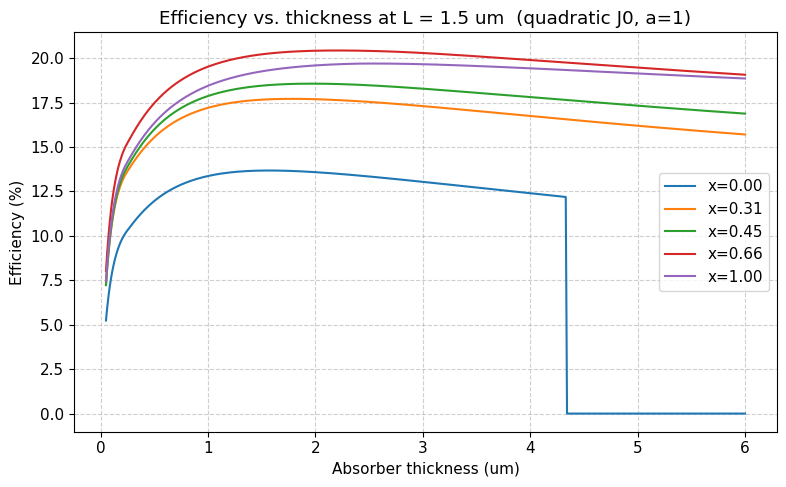

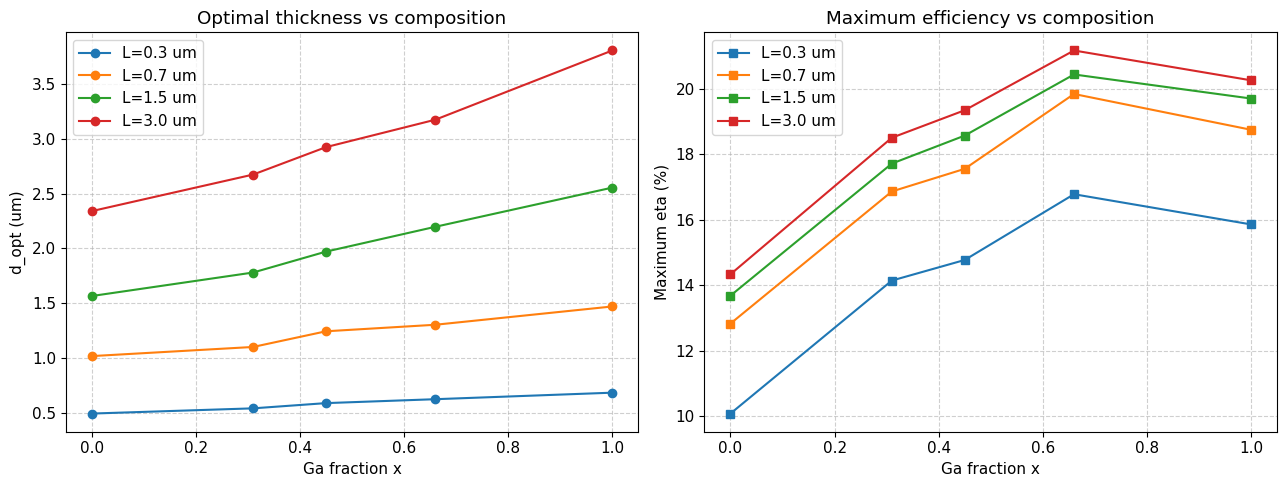


FINAL DESIGN-POINT TABLE (quadratic J0, a=1.0)
   L_um     x   d_opt     eta      Jsc     Voc     FF
   0.30  0.00   0.491   10.08    30.19   0.413  0.680
   0.30  0.31   0.539   14.14    28.46   0.564  0.741
   0.30  0.45   0.587   14.77    25.54   0.636  0.764
   0.30  0.66   0.622   16.78    23.24   0.764  0.794
   0.30  1.00   0.682   15.86    16.09   0.994  0.833
   0.70  0.00   1.016   12.83    37.04   0.427  0.681
   0.70  0.31   1.099   16.86    33.09   0.577  0.742
   0.70  0.45   1.242   17.55    29.79   0.648  0.764
   0.70  0.66   1.302   19.84    27.02   0.777  0.794
   0.70  1.00   1.469   18.75    18.80   1.006  0.833
   1.50  0.00   1.564   13.68    37.67   0.443  0.688
   1.50  0.31   1.779   17.71    33.70   0.592  0.746
   1.50  0.45   1.970   18.57    30.54   0.665  0.768
   1.50  0.66   2.196   20.44    27.26   0.791  0.797
   1.50  1.00   2.554   19.70    19.46   1.020  0.835
   3.00  0.00   2.339   14.33    38.29   0.454  0.693
   3.00  0.31   2.673   18.50    3

In [ ]:
# -*- coding: utf-8 -*-
"""
Part 6/6 : Final production run with the WINNING quadratic form.
Regenerates the main paper figures using physically-grounded
J0_eff = J0(x) * (1 + (d/L)^2)  [Sze Ch.3, alpha_pen=1.0].
"""
import os, numpy as np, matplotlib.pyplot as plt

FINAL_FORM   = 'quadratic'
FINAL_APEN   = 1.0
thickness_um = np.linspace(0.05, 6.0, 500)
thickness_m  = thickness_um * 1e-6
L_um_list    = [0.3, 0.7, 1.5, 3.0]

# Recompute results with winning model
results_final = {L: {} for L in L_um_list}
optima_final  = {L: {} for L in L_um_list}

for L_um in L_um_list:
    for x in x_vals:
        arr = dict(Jsc=np.zeros_like(thickness_m),
                   Voc=np.zeros_like(thickness_m),
                   FF=np.zeros_like(thickness_m),
                   eta=np.zeros_like(thickness_m))
        for i, d in enumerate(thickness_m):
            r = device_metrics_v4(x, d, L_um,
                                  form=FINAL_FORM, alpha_pen=FINAL_APEN)
            arr['Jsc'][i] = r['Jsc']
            arr['Voc'][i] = r['Voc']
            arr['FF'][i]  = r['FF']
            arr['eta'][i] = r['eta']
        results_final[L_um][x] = arr
        idx = int(np.argmax(arr['eta']))
        optima_final[L_um][x] = dict(
            d_opt=thickness_um[idx], eta_max=arr['eta'][idx],
            Jsc_mAcm2=arr['Jsc'][idx]*0.1, Voc=arr['Voc'][idx],
            FF=arr['FF'][idx])

# --- Figure A : Efficiency vs thickness at L=1.5 um (production) ---
plt.figure(figsize=(8, 5))
for x in x_vals:
    plt.plot(thickness_um, results_final[1.5][x]['eta'], label=f"x={x:.2f}")
plt.xlabel("Absorber thickness (um)")
plt.ylabel("Efficiency (%)")
plt.title(f"Efficiency vs. thickness at L = 1.5 um  (quadratic J0, a=1)")
plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "FigA_Eff_vs_d_FINAL.pdf"))
plt.savefig(os.path.join(FIG_DIR, "FigA_Eff_vs_d_FINAL.png"), dpi=300)
plt.show()

# --- Figure B : d_opt and eta_max vs x for all L (production) ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for L_um in L_um_list:
    d_opt   = [optima_final[L_um][x]['d_opt']   for x in x_vals]
    eta_max = [optima_final[L_um][x]['eta_max'] for x in x_vals]
    axes[0].plot(x_vals, d_opt,   'o-', label=f"L={L_um} um")
    axes[1].plot(x_vals, eta_max, 's-', label=f"L={L_um} um")
axes[0].set_xlabel("Ga fraction x"); axes[0].set_ylabel("d_opt (um)")
axes[1].set_xlabel("Ga fraction x"); axes[1].set_ylabel("Maximum eta (%)")
axes[0].set_title("Optimal thickness vs composition")
axes[1].set_title("Maximum efficiency vs composition")
for ax in axes:
    ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "FigB_dopt_etamax_FINAL.pdf"))
plt.savefig(os.path.join(FIG_DIR, "FigB_dopt_etamax_FINAL.png"), dpi=300)
plt.show()

# --- Summary table ---
print("\n" + "=" * 80)
print("FINAL DESIGN-POINT TABLE (quadratic J0, a=1.0)")
print("=" * 80)
print(f"  {'L_um':>5s} {'x':>5s} {'d_opt':>7s} {'eta':>7s} {'Jsc':>8s} "
      f"{'Voc':>7s} {'FF':>6s}")
for L_um in L_um_list:
    for x in x_vals:
        o = optima_final[L_um][x]
        print(f"  {L_um:5.2f} {x:5.2f} {o['d_opt']:7.3f} {o['eta_max']:7.2f} "
              f"{o['Jsc_mAcm2']:8.2f} {o['Voc']:7.3f} {o['FF']:6.3f}")
print("\nPart 6 finished. Use these figures and this table in the manuscript.")
